In [1]:
import os
import numpy as np

import torch
import matplotlib.pyplot as plt

import neuralop

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda'

**Software:**

In [2]:
print("neuralop v" + neuralop.__version__)
print("pytorch v" + torch.__version__)
print("numpy v" + np.__version__)

neuralop v1.0.2
pytorch v2.6.0+cu118
numpy v2.2.4


![title](./imgs/burgers.png)

**Data overview**

In [3]:
from scipy.io import loadmat

In [4]:
data = loadmat("../datasets/burgers_xt/burgers_v100_t100_r1024_N2048.mat")

C:\Users\penki\research\Lib\site-packages\scipy\io\matlab\_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [5]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'input', 'output', 'sigma', 'steps', 'tau', 'tspan', 'None', 'u0eval', 'visc', '__function_workspace__'])

In [6]:
x_data = data['input']
y_data = data['output']

In [7]:
x_data.shape, y_data.shape

((2048, 1024), (2048, 101, 1024))

In [8]:
print("Набор начальных приближений (x_data.mat) формы (B, X): ", x_data.shape)
print("Набор соответствующих решений ур-я Бюргерса (y_data.mat) формы (B, T, X): ", y_data.shape)

Набор начальных приближений (x_data.mat) формы (B, X):  (2048, 1024)
Набор соответствующих решений ур-я Бюргерса (y_data.mat) формы (B, T, X):  (2048, 101, 1024)


In [9]:
idx = 12  # Visualize a single sample.

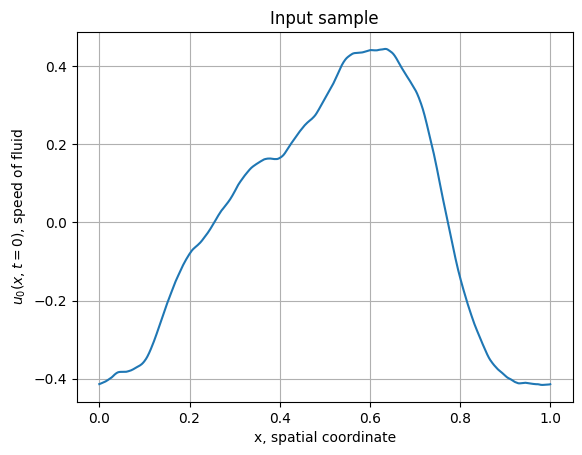

In [10]:
fig, ax = plt.subplots()
x = np.linspace(0, 1, 1024)

ax.plot(x, x_data[idx])
ax.set(xlabel='x, spatial coordinate',
       ylabel=r"$u_{0}(x, t=0)$, speed of fluid",
       title='Input sample')
ax.grid()

plt.show()

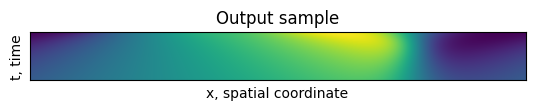

In [11]:
fig, ax = plt.subplots()

ax.imshow(y_data[idx])
ax.set(xticks=[], yticks=[], ylabel="t, time", xlabel="x, spatial coordinate",
       title='Output sample')

plt.show()